https://humaticlabs.com/blog/mrdmd-python/

https://pydmd.github.io/PyDMD/tutorial3mrdmd.html

https://pydmd.github.io/PyDMD/mrdmd.html

https://github.com/kdmarrett/dmd

## installs

In [ ]:
!git clone https://github.com/mathLab/PyDMD.git

Cloning into 'PyDMD'...
remote: Enumerating objects: 6693, done.
remote: Counting objects: 100% (493/493), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 6693 (delta 433), reused 412 (delta 412), pack-reused 6200 (from 2)
Receiving objects: 100% (6693/6693), 284.99 MiB | 18.97 MiB/s, done.
Resolving deltas: 100% (4294/4294), done.
Updating files: 100% (276/276), done.


In [ ]:
import sys
sys.path.append('/content/PyDMD')
import warnings
warnings.filterwarnings("ignore")

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from pydmd import MrDMD, DMD, BOPDMD
from pydmd.plotter import plot_eigs_mrdmd
import numpy as np
import pandas as pd

import plotly

## functions

In [ ]:
def create_sample_data():
    x = np.linspace(-10, 10, 80)
    t = np.linspace(0, 20, 1600)
    Xm, Tm = np.meshgrid(x, t)

    D = np.exp(-np.power(Xm / 2, 2)) * np.exp(0.8j * Tm)
    D += np.sin(0.9 * Xm) * np.exp(1j * Tm)
    D += np.cos(1.1 * Xm) * np.exp(2j * Tm)
    D += 0.6 * np.sin(1.2 * Xm) * np.exp(3j * Tm)
    D += 0.6 * np.cos(1.3 * Xm) * np.exp(4j * Tm)
    D += 0.2 * np.sin(2.0 * Xm) * np.exp(6j * Tm)
    D += 0.2 * np.cos(2.1 * Xm) * np.exp(8j * Tm)
    D += 0.1 * np.sin(5.7 * Xm) * np.exp(10j * Tm)
    D += 0.1 * np.cos(5.9 * Xm) * np.exp(12j * Tm)
    D += 0.1 * np.random.randn(*Xm.shape)
    D += 0.03 * np.random.randn(*Xm.shape)
    D += (
        5
        * np.exp(-np.power((Xm + 5) / 5, 2))
        * np.exp(-np.power((Tm - 5) / 5, 2))
    )
    D[:800, 40:] += 2
    D[200:600, 50:70] -= 3
    D[800:, :40] -= 2
    D[1000:1400, 10:30] += 3
    D[1000:1080, 50:70] += 2
    D[1160:1240, 50:70] += 2
    D[1320:1400, 50:70] += 2
    return D.T

In [ ]:
def make_plot(X, x=None, y=None, figsize=(12, 8), title=""):
    """
    Plot of the data X
    """
    plt.figure(figsize=figsize)
    plt.title(title)
    X = np.real(X)
    CS = plt.pcolor(x, y, X)
    cbar = plt.colorbar(CS)
    plt.xlabel("Space")
    plt.ylabel("Time")
    plt.show()

## import island data

In [ ]:
# Step 1: Load the dataset
#url = "https://raw.githubusercontent.com/Wzesk/littoral/refs/heads/main/toy_island/data_exchange/Vakharu_001.csv"
url = "https://github.com/Wzesk/littoral/blob/e35aecfe379207a8ecc49b0c3faf6d3ec5efacf0/toy_island/data_exchange/raw_island_days.csv?raw=true"
#url = "https://raw.githubusercontent.com/Wzesk/littoral/refs/heads/main/toy_island/data_exchange/un_transect_sine_test.csv"
data = pd.read_csv(url)
data.fillna(0, inplace=True)
time = pd.to_datetime(data.iloc[:, 0]).tolist()
spatial_data = np.array([np.array(row[1:], dtype=float) for row in data.itertuples(index=False)])

# Step 2: Prepare the data
# Assume the dataset has time as rows and points along the shore as columns
# If needed, transpose the dataset to match this structure
data_matrix = spatial_data.T

In [ ]:
data_matrix.shape

(20, 27001)

In [ ]:
#data_matrix=data_matrix[:80,:1600]

In [ ]:
#normalize data_matrix
norm_data_matrix = (((data_matrix - np.min(data_matrix)) / (np.max(data_matrix) - np.min(data_matrix))) *2 ) - 1

## sample data

In [ ]:
#sample_data = create_sample_data()
sample_data = norm_data_matrix

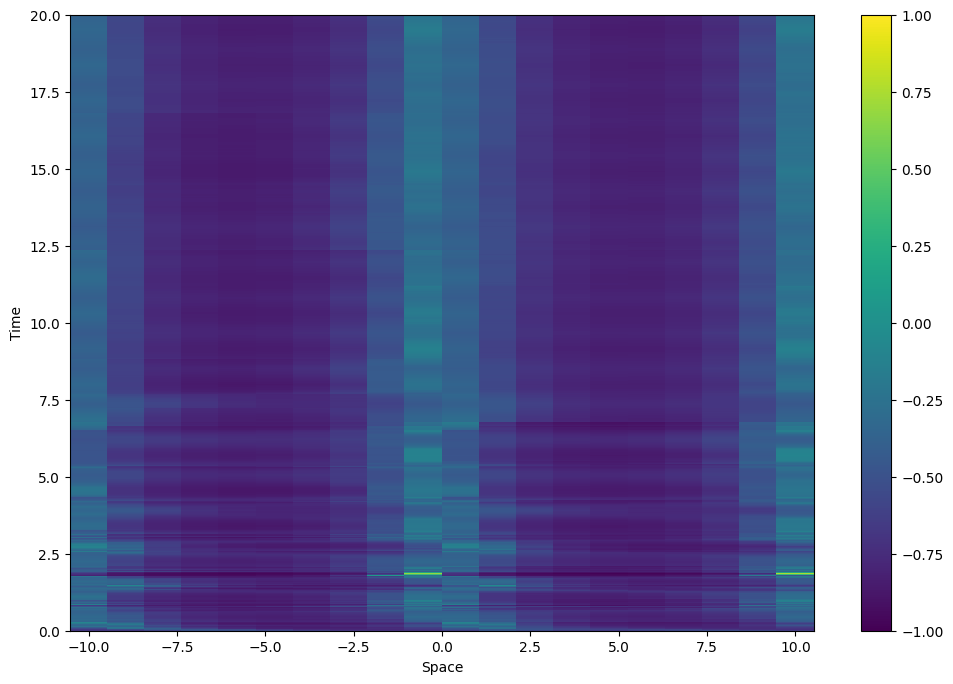

In [ ]:
x = np.linspace(-10, 10, data_matrix.shape[0])
t = np.linspace(0, 20, data_matrix.shape[1])
make_plot(sample_data.T, x=x, y=t)

First we apply the classical DMD without the svd rank truncation, and then we try to reconstruct the data. You can clearly see that all the transient time events are missing.

In [ ]:
first_dmd = DMD(svd_rank=-1)
first_dmd.fit(X=sample_data)
make_plot(first_dmd.reconstructed_data.T, x=x, y=t)


BOPDMD (bag optimized is typically better for realworld data

In [ ]:
# first_dmd = DMD(svd_rank=-1)
# first_dmd.BO
# first_dmd.fit(X=sample_data)
# make_plot(first_dmd.reconstructed_data.T, x=x, y=t)

# bopdmd = BOPDMD(
#     svd_rank=12,                                  # Rank of the DMD fit.
#     num_trials=100,                               # Number of bagging trials to perform.
#     trial_size=0.5,                               # Use 50% of the total number of snapshots per trial.
#     eig_constraints={"imag", "conjugate_pairs"},  # Eigenvalues must be imaginary and conjugate pairs.
#     varpro_opts_dict={"tol":0.2, "verbose":True}, # Set convergence tolerance and use verbose updates.
# )

# # Fit the BOP-DMD model.
# # X = (n, m) numpy array of time-varying snapshot data
# # t = (m,) numpy array of times of data collection
# bopdmd.fit(X=sample_data)
# make_plot(bopdmd.reconstructed_data.T, x=x, y=t)

Now we do the same but using the mrDMD instead. The result is remarkable even with the svd rank truncation (experiment changing the input parameters).

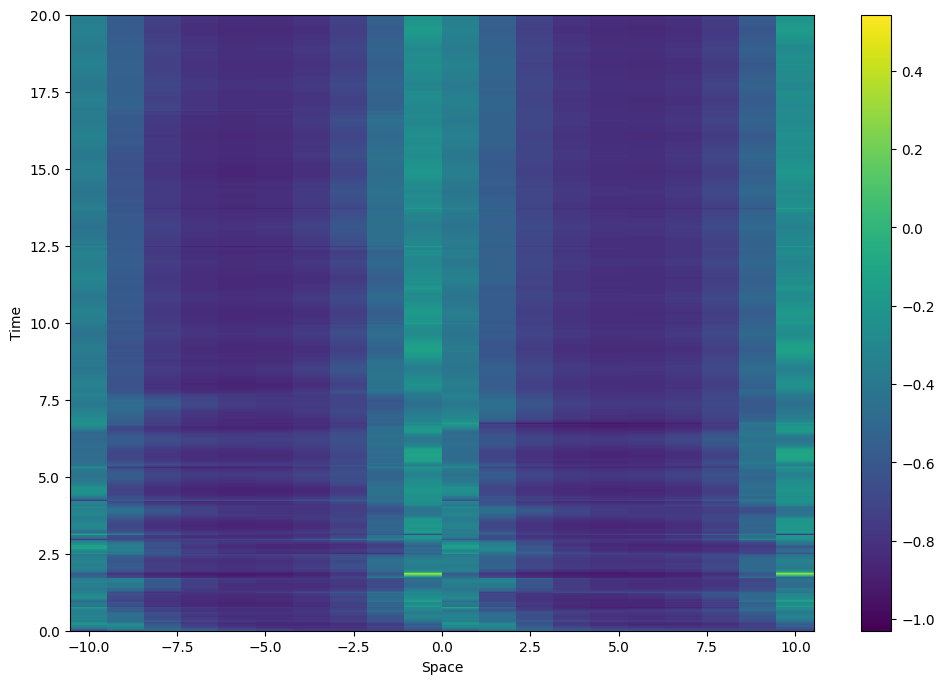

In [ ]:
sub_dmd = DMD(svd_rank=-1)

dmd = MrDMD(sub_dmd, max_level=7, max_cycles=1)
dmd.fit(X=sample_data)

pred_data = dmd.reconstructed_data.T

# #if values in pred)data are less than -10, set them to -10
# pred_data[pred_data < -20] = -20
# #if values are greater than `10 set them to 10
# pred_data[pred_data > 20] = 20

make_plot(pred_data, x=x, y=t)

Ok, pretty amazing eh? Let us have a look at the eigenvalues in order to better understand the mrDMD. Without truncation we have 80 eigenvalues.

The number of eigenvalues is 708


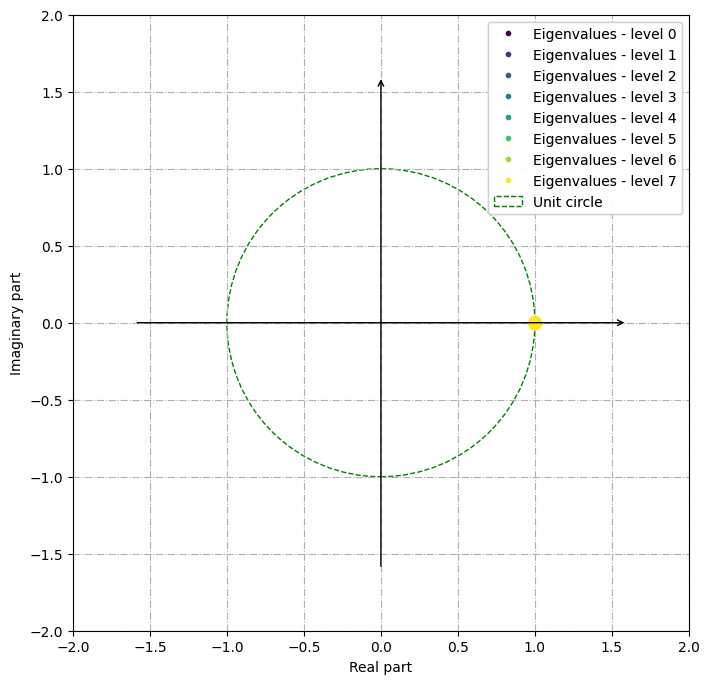

In [ ]:
print("The number of eigenvalues is {}".format(dmd.eigs.shape[0]))
plot_eigs_mrdmd(dmd, show_axes=True, show_unit_circle=True, figsize=(8, 8))

It is also possible to plot only specific eigenvalues, given the level and the node. If the node is not provided all the eigenvalues of that level will be plotted.

ValueError: zero-size array to reduction operation maximum which has no identity

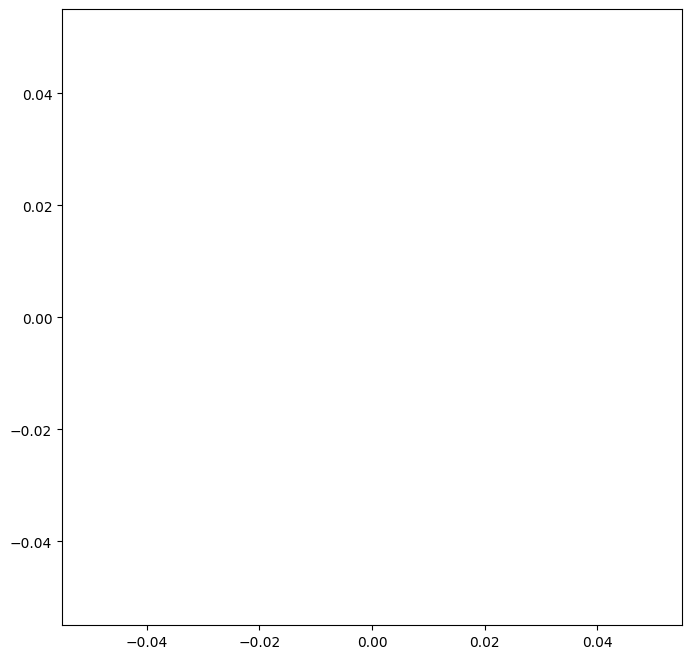

In [ ]:
plot_eigs_mrdmd(
    dmd, show_axes=True, show_unit_circle=True, figsize=(8, 8), level=3, node=0
)

The idea is to extract the slow modes at each iteration, where a slow mode is a mode with a relative low frequency. This just means that the mode changes somewhat slowly as the system evolves in time. Thus the mrDMD is able to catch different time events.

The general mrDMD algorithm is as follows:

Compute DMD for available data.

1.   Determine fast and slow modes.
2.   Find the best DMD approximation to the available data constructed from the slow modes only.
3.    Subtract off the slow-mode approximation from the available data.
4.    Split the available data in half.
5.    Repeat the procedure for the first half of data (including this step).
6.    Repeat the procedure for the second half of data (including this step).


Let us have a look at the modes for the first two levels and the corresponding time evolution. At the first level we have two very slow modes, while at the second one there are 5 modes.

In [ ]:
pmodes = dmd.partial_modes(level=3)
fig = plt.plot(x, pmodes.real)

In [ ]:
pmodes = dmd.partial_modes(level=4)
fig = plt.plot(x, pmodes.real)

In [ ]:
pdyna = dmd.partial_dynamics(level=3)
fig = plt.plot(t, pdyna.real.T)

Notice the discontinuities in the time evolution where the data were split.

In [ ]:
pdyna = dmd.partial_dynamics(level=3)
print("The number of modes in the level number 3 is {}".format(pdyna.shape[0]))
fig = plt.plot(t, pdyna.real.T)

Now we recreate the original data by adding levels together. For each level, starting with the first (note that the starting index is 0), we construct an approximation of the data.

In [ ]:
pdata = dmd.partial_reconstructed_data(level=0)
make_plot(pdata.T, x=x, y=t, title="level 0", figsize=(7.5, 5))

Then, we sequentially add them all together, one on top of another. It is interesting to see how the original data has been broken into features of finer and finer resolution.

In [ ]:
pdata = dmd.partial_reconstructed_data(level=0)
for i in range(1, 7):

    level = dmd.partial_reconstructed_data(level=i)

    # #if values in pred)data are less than -10, set them to -10
    # level[level < -20] = -20
    # #if values are greater than `10 set them to 10
    # level[level > 20] = 20

    pdata += level

    make_plot(pdata.T, x=x, y=t, title="levels 0-" + str(i), figsize=(7.5, 5))